# **3. Modelado Scikit-Learn - Click-Through Rate**

## **Importación librerías**

Se importan las librerías necesarias para el modelado, se importan herramientas para división de datos y  preprocesamiento.

In [1]:
import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

## **Carga Dataframes**

Se procede a cargar el dataframe resultante del análisis exploratorio, Adicionalmente, se estandarizan los nombres de las columnas reemplazando espacios por guiones bajos y convirtiendo todo a minúsculas, con el fin de facilitar su manipulación.

In [13]:
df = pd.read_csv(os.path.join(os.getcwd(), r'datos\train\train_sklearn_model.csv'))
df.columns = df.columns.str.replace(' ', '_').str.lower()

### **Observamos encabezado del dataframe**

In [15]:
print(df.head().to_string())

   click  hour    c1  banner_pos site_domain site_category app_domain app_category device_model  device_type  device_conn_type    c14  c15  c16   c17  c18   c19     c20  c21   año  mes  dia
0      0    19  1005           0    c4e18dd6      50e219e0   d9b5648e     0f2161f8     72a00661            1                 0  20277  320   50  2281    3    47  100182   42  2014   10   23
1      0    13  1005           0    f3845767      28905ebd   7801e8d9     07d7df22     3bd9e8e7            1                 0  15705  320   50  1722    0    35      -1   79  2014   10   24
2      0     5  1005           0    f3845767      28905ebd   7801e8d9     07d7df22     1f0bc64f            1                 0  20108  320   50  2299    2  1327  100084   52  2014   10   28
3      0    11  1005           0    c4e18dd6      50e219e0   2347f47a     0f2161f8     421872ab            1                 0  20170  300   50  2312    0   167  100079   16  2014   10   29
4      0    20  1005           0    c4e18dd6      

### **Separación tipo de variables y eliminación de variables innecesarias**

Se realiza una separación de las variables según su tipo y se procede a eliminar aquellas que no aportan valor predictivo al modelo. En particular, se descartan las columnas `c14`, `año`, `mes` y `dia`.

In [16]:
df = df.drop(columns=['c14', 'año', 'mes', 'dia'])

Seleccionamos aquellas variables útiles para el modelado.

In [17]:
var_anon = ['c1','c15','c16','c17','c18','c19','c20','c21']
var_cat = ['device_model', 'site_domain', 'app_domain', 'app_category','site_category','banner_pos','device_type','device_conn_type', 'hour']

In [18]:
df.shape

(1000000, 18)

In [19]:
print(df.head().to_string())

   click  hour    c1  banner_pos site_domain site_category app_domain app_category device_model  device_type  device_conn_type  c15  c16   c17  c18   c19     c20  c21
0      0    19  1005           0    c4e18dd6      50e219e0   d9b5648e     0f2161f8     72a00661            1                 0  320   50  2281    3    47  100182   42
1      0    13  1005           0    f3845767      28905ebd   7801e8d9     07d7df22     3bd9e8e7            1                 0  320   50  1722    0    35      -1   79
2      0     5  1005           0    f3845767      28905ebd   7801e8d9     07d7df22     1f0bc64f            1                 0  320   50  2299    2  1327  100084   52
3      0    11  1005           0    c4e18dd6      50e219e0   2347f47a     0f2161f8     421872ab            1                 0  300   50  2312    0   167  100079   16
4      0    20  1005           0    c4e18dd6      50e219e0   2347f47a     0f2161f8     8e39e528            1                 2  320   50  2655    2    38      -1   2

Observamos tipos de datos por variable.

In [20]:
df.dtypes

click                int64
hour                 int64
c1                   int64
banner_pos           int64
site_domain         object
site_category       object
app_domain          object
app_category        object
device_model        object
device_type          int64
device_conn_type     int64
c15                  int64
c16                  int64
c17                  int64
c18                  int64
c19                  int64
c20                  int64
c21                  int64
dtype: object

### **Conversión variables categóricas**

Se convierten las variables categóricas y anónimas al tipo `str` para garantizar que sean tratadas adecuadamente como variables categóricas durante el proceso de codificación.

In [21]:
for var in var_anon+var_cat:
    df[var] = df[var].astype('str')

In [22]:
df.dtypes

click                int64
hour                object
c1                  object
banner_pos          object
site_domain         object
site_category       object
app_domain          object
app_category        object
device_model        object
device_type         object
device_conn_type    object
c15                 object
c16                 object
c17                 object
c18                 object
c19                 object
c20                 object
c21                 object
dtype: object

### **Agrupar categorías con pocas instancias**

Procedemos a agrupar categorías en aquellas variables de alta cardinalidad.

In [23]:
df.nunique()

click                  2
hour                  24
c1                     7
banner_pos             7
site_domain         2856
site_category         22
app_domain           201
app_category          27
device_model        5134
device_type            5
device_conn_type       4
c15                    8
c16                    9
c17                  422
c18                    4
c19                   67
c20                  164
c21                   60
dtype: int64

Establecemos un umbral de 5000 observaciones para agrupar categorías poco frecuentes, lo que representa menos del 0.005% del total de registros. La agrupación se aplica sobre las tres variables con mayor cardinalidad: `device_model`, `site_domain`, `c17`.

In [25]:
for var in ['device_model', 'site_domain', 'c17']:

    freq = df[var].value_counts()
    rare = freq[freq < 5000].index
    df[var] = df[var].replace(rare, 'OTHER')

Observamos el resultado de la agrupación.

In [26]:
df.nunique()

click                 2
hour                 24
c1                    7
banner_pos            7
site_domain          25
site_category        22
app_domain          201
app_category         27
device_model         37
device_type           5
device_conn_type      4
c15                   8
c16                   9
c17                  51
c18                   4
c19                  67
c20                 164
c21                  60
dtype: int64

## **Separación variables predictoras - variable objetivo**

Se separa el conjunto de datos en variables predictoras y variable objetivo. La variable `click` es asignada a `y` como target, mientras que el resto de las columnas se almacenan en `X` como features para el modelado.

In [27]:
X = df.drop('click', axis=1)
y = df['click']

### **Encabezado conjunto de entrenamiento**

In [28]:
X.head()

,hour,c1,banner_pos,site_domain,site_category,app_domain,app_category,device_model,device_type,device_conn_type,c15,c16,c17,c18,c19,c20,c21
0,19,1005,0,c4e18dd6,50e219e0,d9b5648e,0f2161f8,OTHER,1,0,320,50,2281,3,47,100182,42
1,13,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,3bd9e8e7,1,0,320,50,1722,0,35,-1,79
2,5,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,1f0bc64f,1,0,320,50,2299,2,1327,100084,52
3,11,1005,0,c4e18dd6,50e219e0,2347f47a,0f2161f8,OTHER,1,0,300,50,OTHER,0,167,100079,16
4,20,1005,0,c4e18dd6,50e219e0,2347f47a,0f2161f8,OTHER,1,2,320,50,OTHER,2,38,-1,23


### **Encabezado variable de interés**

In [29]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: click, dtype: int64

## **Separación conjunto Train - Test**

Se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) utilizando `train_test_split`. Se emplea el parámetro` stratify=y` para mantener la misma proporción de la variable objetivo en ambos conjuntos, asegurando que la distribución de clicks y no clicks sea representativa.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [31]:
X_train.shape

(800000, 17)

## **Modelado Scikit-Learn**

### **Preprocesamiento de variables**

Utilizamos `Target Encoding` para las variables anónimas y categóricas (`var_anon` y `var_cat`). Se emplea el parámetro `smooth='auto'` para suavizar las estimaciones en categorías con pocas observaciones.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(smooth='auto'), var_anon+var_cat)
    ]
)


### **Pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone

mlp = MLPClassifier(
    random_state=42
)

mlp = MLPClassifier(random_state=42)

pipe = Pipeline([
    ('prep', preprocessor),
    ('scaler', StandardScaler()), 
    ('model', mlp)
])

### **Tuning Hiperparámetros**

Se define un grid de hiperparámetros para optimizar el `MLPClassifier`:

* `model__hidden_layer_sizes`: Arquitectura de la red neuronal, probando una capa oculta con 50 y 100 neuronas, y dos capas ocultas con 100 y 50 neuronas respectivamente.

* `model__alpha`: Parámetro de regularización para controlar el sobreajuste, evaluando valores de 0.0001, 0.001 y 0.01.

* `model__max_iter`: Número máximo de iteraciones para el entrenamiento, probando con 50 y 100 épocas.

In [36]:
param_grid = {
    'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__max_iter': [50, 100]
}

### **GridSearch**

In [37]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

Se configura una búsqueda en malla utilizando `GridSearchCV` para encontrar la combinación óptima de hiperparámetros:

`pipe`: Pipeline previamente definido que incluye preprocesamiento y modelo.

`param_grid`: Conjunto de hiperparámetros a evaluar definido anteriormente.

`scoring='roc_auc'`: Métrica de evaluación basada en el área bajo la curva ROC, adecuada para problemas de clasificación binaria con posibles desbalances.

`cv=5`: Validación cruzada de 5 particiones para evaluar cada combinación.

`n_jobs=-1`: Utiliza todos los núcleos disponibles para acelerar el proceso.

`verbose=1`: Muestra el progreso de la búsqueda durante la ejecución.

### **Entrenamiento**

In [40]:
import time

start_train = time.time()
grid.fit(X_train, y_train)
train_time = time.time() - start_train

print(f"Tiempo de entrenamiento: {train_time:.1f}s")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tiempo de entrenamiento: 1801.6s


Se registra el tiempo de entrenamiento del modelo para evaluar su costo computacional. La búsqueda con `GridSearchCV` ajusta 5 folds para cada uno de los 18 candidatos, totalizando 90 fits. El proceso completo tomó 1801.6 segundos, equivalentes a aproximadamente 30 minutos.

## **Test y métricas**

In [42]:
model_num = grid.best_estimator_

y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Mejor configuración:", grid.best_params_)
print("\nAUC:", roc_auc_score(y_test, y_prob))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Mejor configuración: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__max_iter': 100}

AUC: 0.7250403049453604

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    166053
           1       0.60      0.06      0.10     33947

    accuracy                           0.83    200000
   macro avg       0.72      0.52      0.51    200000
weighted avg       0.80      0.83      0.77    200000


Matriz de confusión:
[[164773   1280]
 [ 32007   1940]]


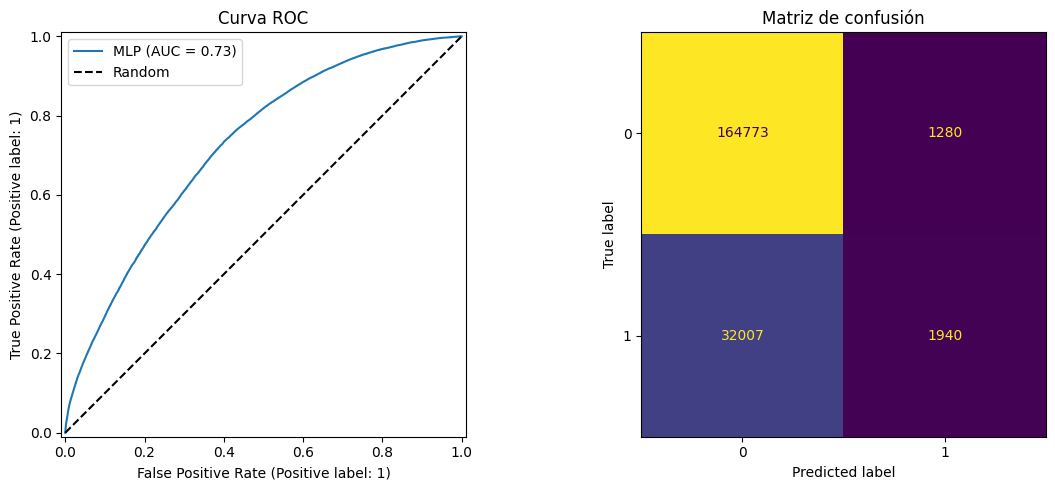

In [44]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=axes[0],
    name='MLP'
)
axes[0].set_title('Curva ROC')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

La mejor configuración encontrada por GridSearchCV corresponde a una arquitectura de dos hidden layer con 100 y 50 neuronas respectivamente

* `alpha`: 0.0001

* `Iteraciones máximas`: 100

**Rendimiento general:**

`AUC`: 0.725, indicando una capacidad predictiva moderada para distinguir entre clases.

**Análisis por clase:**

* **Clase 0 (no click)**: Excelente desempeño con precisión de 0.84 y recall de 0.99, logrando identificar correctamente casi todos los no clics.

* **Clase 1 (click)**: Desempeño pobre, con recall de solo 0.06. Esto significa que el modelo detecta únicamente el 6% de los clics reales, aunque cuando predice un clic, acierta en el 60% de los casos (precisión 0.60).

**Matriz de confusión:**

* `Verdaderos negativos`: 164,773

* `Falsos positivos`: 1,280

* `Falsos negativos`: 32,007

* `Verdaderos positivos`: 1,940

El modelo presenta un claro desbalance en su rendimiento, inclinándose fuertemente hacia la clase mayoritaria (no click). El bajo recall en clicks indica que el modelo no está logrando capturar bien los patrones de la clase minoritaria, posiblemente por la naturaleza poco común de los clicks o porque las variables no logran discriminarlo adecuadamente.

## **Interpretabilidad con LIME**

Para generar explicaciones locales e interpretables de las predicciones del modelo, se inicializa el explanador LIME para datos tabulares. Esta herramienta permite desglosar predicciones individuales identificando el aporte específico de cada variable en un instancia particular, facilitando la transparencia del modelo y la validación de sus criterios de decisión.

In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

best_model = grid.best_estimator_

prep = best_model.named_steps['prep']
scaler = best_model.named_steps['scaler']
mlp_model = best_model.named_steps['model']

X_train_transformed = scaler.transform(prep.transform(X_train))
X_test_transformed  = scaler.transform(prep.transform(X_test))

def predict_fn(data):
    return mlp_model.predict_proba(data)

y_pred_array = np.array(y_pred)
y_test_array = np.array(y_test)

idx = 8

print(f"Índice: {idx}")
print(f"Valor real: {y_test_array[idx]}")
print(f"Valor predicho: {y_pred_array[idx]}")

Índice: 8
Valor real: 1
Valor predicho: 0


En el anterior código extraemos los componentes del pipeline entrenado, de ese pipeline se extraen las tres etapas por separado, el preprocesador (`TargetEncoder`), el scaler (`StandardScaler`), y el modelo MLP. Posteriormente, se aplica el `TargetEncoder` con `prep.transform(X_train)` que convierte las variables categóricas a numéricas, y luego `scaler.transform()` que estandariza esos valores. Por último, `predict_fn` es una función que LIME va a llamar internamente para obtener probabilidades de la instancia, además, seleccionamos la instancia número 8 del conjunto test para evaluar las características que influyen en la clasificación erronea.

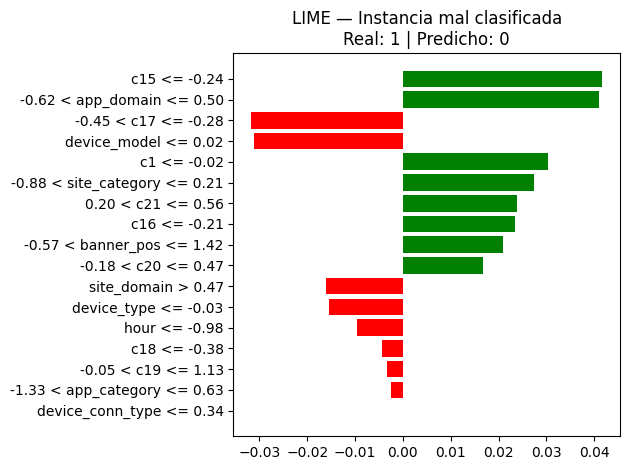

In [52]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=var_anon+var_cat,
    class_names=['no click', 'click'],
    mode='classification',
    random_state=42
)

explanation = explainer.explain_instance(
    data_row=X_test_transformed[8],
    predict_fn=predict_fn,
    num_features=20
)

fig = explanation.as_pyplot_figure()
plt.title(f"LIME — Instancia mal clasificada\nReal: {y_test_array[idx]} | Predicho: {y_pred_array[idx]}")
plt.tight_layout()
plt.show()

### **Interpetación**

La mayoría de features empujaban en la dirección correcta (colores verdes). `c15` <= -0.24 y `app_domain` con valores entre -0.62 y 0.50 son las que más fuerza tenían hacia predecir click, seguidas de `c1`, `site_category`, `c16`, `c21`, `banner_pos` y `c20` con contribuciones moderadas.

Solo dos features empujaron de manera significativa en la predicción equivocada, pero con bastante fuerza: `c17` con valores -0.45 y -0.28, y `device_model` <= 0.02. Estas dos features fueron suficientemente influyentes para que el modelo ignorara todas las señales verdes y predijera no click.
